# Comparing Pedestal Models

Can we get away with fewer coefficients in our model?

The full-up model has the form:
$$
y = a + b t_{exp} \exp{T_{det0} / c} + d T_{det0} + e T_{det0}^2 + f T_{ADC},
$$
We want to know how few parameters we can reasonably get away with. We start by fixing $f$ per segment of the detector which we know yields nearly equivalent results to the full model.
We'll then steadily drop out parameters from the model and compare the pedestal-subtracted data in each case.
For these reduced parameter sets, we will only fit to points where the detector temperature was below zero.

In [17]:
import pathlib
import astropy.units as u
import xarray
import matplotlib.pyplot as plt
import numpy as np
import dask.array
import distributed
import scipy.stats

from astropy.visualization import ImageNormalize, AsymmetricPercentileInterval, LogStretch

In [2]:
#client = distributed.Client(address='tcp://127.0.0.1:41691')

In [2]:
data_dir = pathlib.Path('../data/moxsi_gsfc_calibration_images/')

In [3]:
ds = xarray.open_zarr(data_dir / 'images.zarr')
# Load a small chunk straight into memory. This chunk was selected to avoid the pinholes, alignment holes, and slots/slits
det_slice = np.s_[1275:1525, :]
ds = ds.isel(row=det_slice[0], column=det_slice[1]).compute()

In [4]:
da_coeffs_all = xarray.open_dataarray(data_dir / 'fit_coefficients.nc')[det_slice].compute()
da_coeffs_all_subzero = xarray.open_dataarray(data_dir / 'fit_coefficients_full_subzero.nc')[det_slice].compute()
da_coeffs_a = xarray.open_dataarray(data_dir / 'fit_coefficients_a_fixed_f_subzero.nc')[det_slice].compute()
da_coeffs_ad = xarray.open_dataarray(data_dir / 'fit_coefficients_ad_fixed_f_subzero.nc')[det_slice].compute()
da_coeffs_abcd = xarray.open_dataarray(data_dir / 'fit_coefficients_adbc_fixed_f_subzero.nc')[det_slice].compute()
da_coeffs_ade = xarray.open_dataarray(data_dir / 'fit_coefficients_ade_fixed_f_subzero.nc')[det_slice].compute()

Below are the maps of the parameters for the full model.

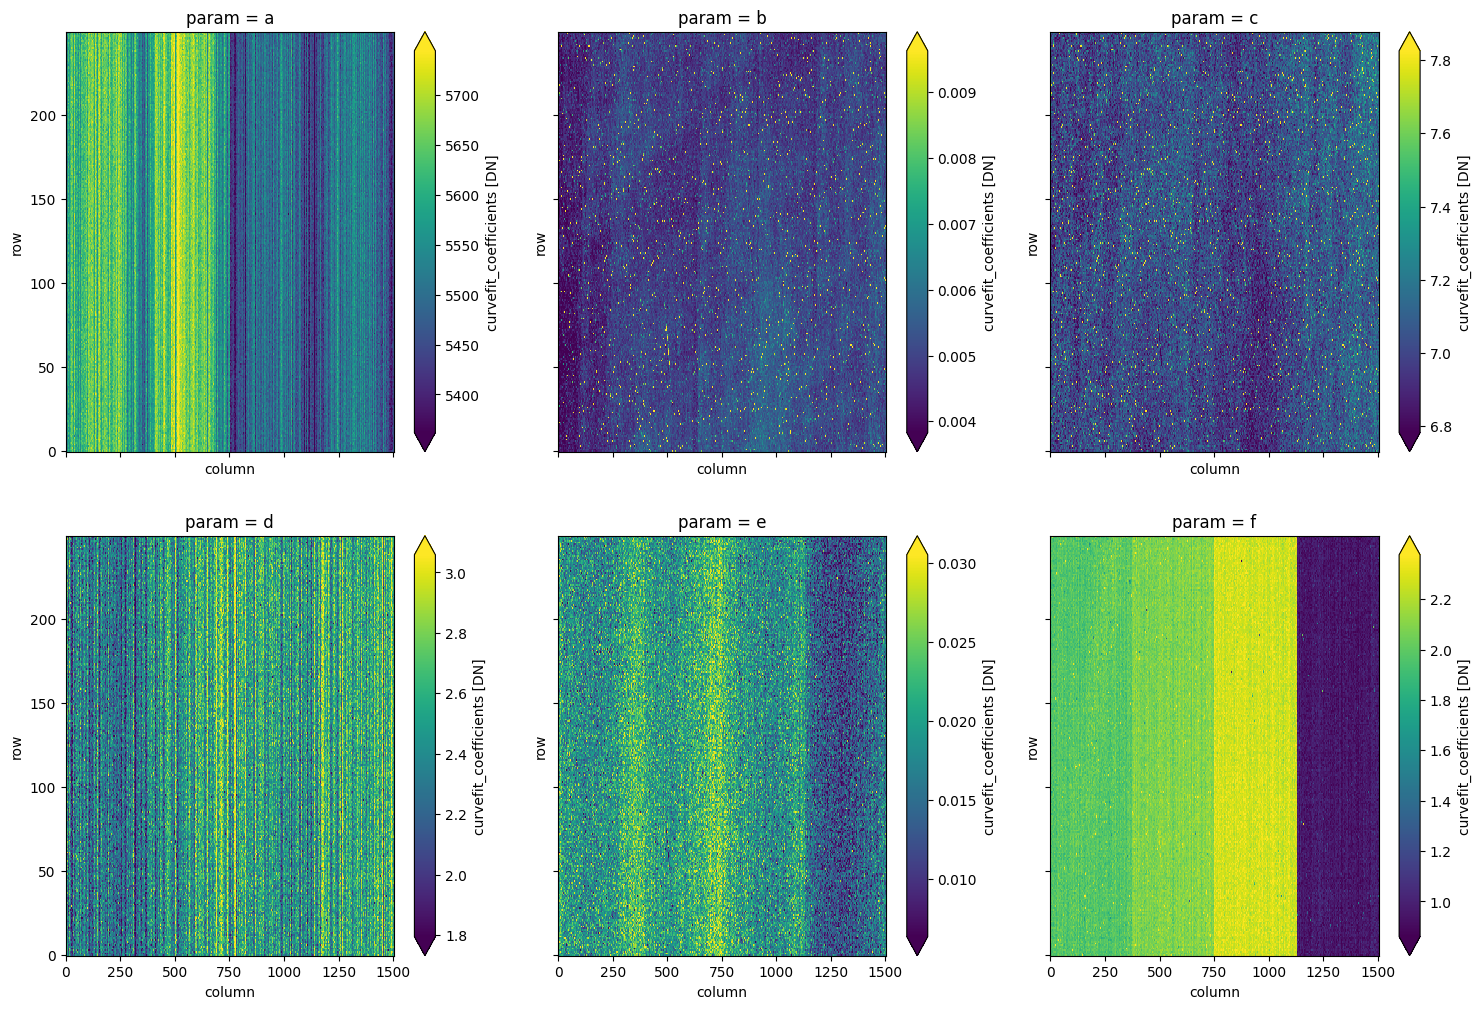

In [5]:
size = 6 
fig,axes = plt.subplots(2,3,figsize=(size*3,size*2),sharex=True,sharey=True)
for i,ax in enumerate(axes.flatten()):
    vmin, vmax = AsymmetricPercentileInterval(1,99).get_limits(da_coeffs_all[...,i].data)
    da_coeffs_all[...,i].plot.imshow(ax=ax, vmin=max(0,vmin), vmax=vmax)

In [6]:
range_dict = {'a': [5200,5800], 'b': [0.002, 0.01], 'c': [5,10.0], 'd': [0.5,5], 'e': [0.002,0.07], 'f': [0.5,3.0]}

Next, compare the distribution of fit parameters for all cases.

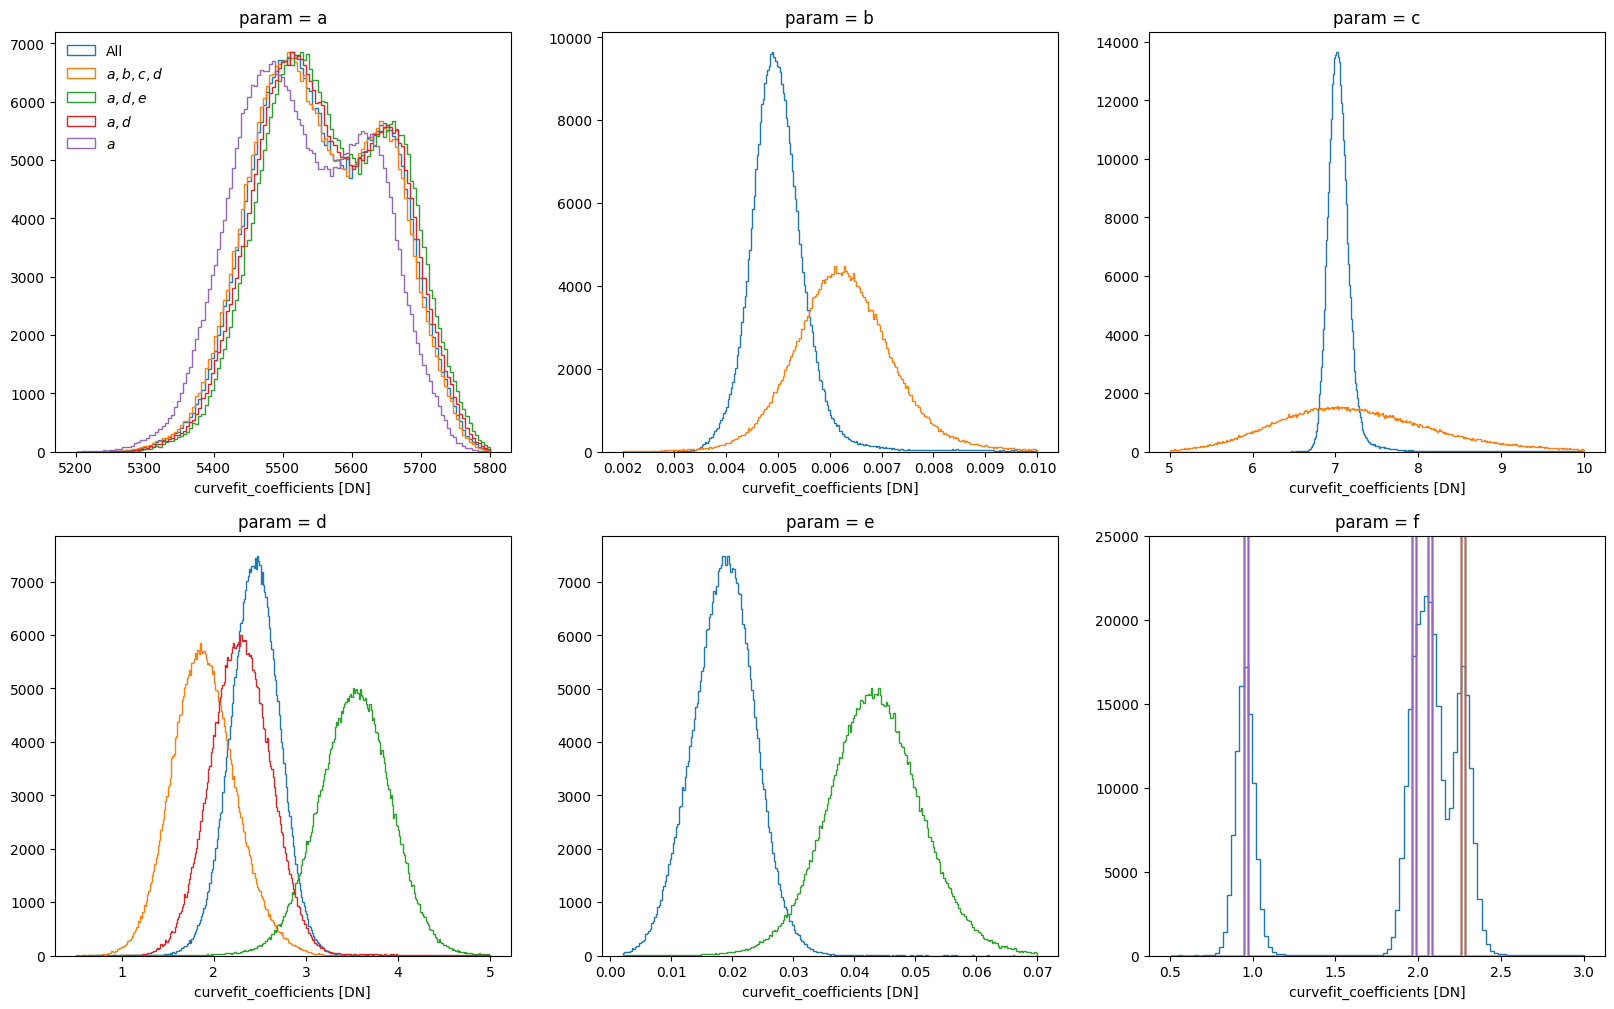

In [7]:
fig,axes = plt.subplots(2,3,figsize=(20,12),sharex=False,sharey=False)
bin_edges = {}
for i,(ax,param) in enumerate(zip(axes.flatten(),da_coeffs_all.param.data)):
    if (range := range_dict.get(str(param))) is None:
        range = AsymmetricPercentileInterval(0.5,99.5).get_limits(da_coeffs_all[...,i].data)
    _,be,_ = da_coeffs_all.sel(param=param).plot.hist(ax=ax, bins='scott', range=range, histtype='step', log=False, label='All', color='C0')
    #_ = da_coeffs_all_subzero.sel(param=param).plot.hist(ax=ax, bins=be, histtype='step', log=False, label='All subzero', color='C1')
    if param in da_coeffs_abcd.param:
        _ = da_coeffs_abcd.sel(param=param).plot.hist(ax=ax, bins=be, histtype='step', log=False, label=r'$a,b,c,d$', color='C1')
    if param in da_coeffs_ade.param:
        _ = da_coeffs_ade.sel(param=param).plot.hist(ax=ax, bins=be, histtype='step', log=False, label=r'$a,d,e$', color='C2')
    if param in da_coeffs_ad.param:
        _ = da_coeffs_ad.sel(param=param).plot.hist(ax=ax, bins=be, histtype='step', log=False, label=r'$a,d$', color='C3')
    if param in da_coeffs_a.param:
        _ = da_coeffs_a.sel(param=param).plot.hist(ax=ax, bins=be, histtype='step', log=False, label=r'$a$', color='C4')
    if param == 'f':
        ax.set_ylim(0,2.5e4)
    if param == 'a':
        ax.legend(loc=2, frameon=False)
    #bin_edges[str(da_coeffs_full.param[i].data)] = be
    #vmin, vmax = AsymmetricPercentileInterval(0.5,99).get_limits(da_coeffs[...,i].data)
    #_,be,_ = da_coeffs[...,i].plot.hist(ax=ax, bins='scott', range=(vmin,vmax), histtype='step', log=False)

Now, compare evaluated pedestal from each model subtracted from the data and look at the distribution of points. When doing this, make sure to only select the points below zero.

In [8]:
def pedestal_func(ds, coeffs):
    t_det0 = ds.temperature_detector_0
    exposure = ds.exposure_time
    t_adc = ds.temperature_adc
    # All test models have a and f terms
    ped = coeffs.sel(param='a') + coeffs.sel(param='f') * t_adc
    if 'b' in coeffs.param and 'c' in coeffs.param:
        ped += coeffs.sel(param='b') * exposure * np.exp(t_det0 / coeffs.sel(param='c'))
    if 'd' in coeffs.param:
        ped += coeffs.sel(param='d') * t_det0
    if 'e' in coeffs.param:
        ped += coeffs.sel(param='e') * t_det0**2
    return ped

In [9]:
is_subzero = np.where(np.logical_and(ds.temperature_detector_0<0, ds.temperature_detector_1<0))
ds_subzero = ds.isel(sample=is_subzero[0])

In [10]:
pedestal_all = pedestal_func(ds_subzero, da_coeffs_all)
ped_rem_all = ds_subzero['data'] - pedestal_all

In [11]:
pedestal_a = pedestal_func(ds_subzero, da_coeffs_a)
ped_rem_a = ds_subzero['data'] - pedestal_a

In [12]:
pedestal_ad = pedestal_func(ds_subzero, da_coeffs_ad)
ped_rem_ad = ds_subzero['data'] - pedestal_ad

In [13]:
pedestal_abcd = pedestal_func(ds_subzero, da_coeffs_abcd)
ped_rem_abcd = ds_subzero['data'] - pedestal_abcd

In [14]:
pedestal_ade = pedestal_func(ds_subzero, da_coeffs_ade)
ped_rem_ade = ds_subzero['data'] - pedestal_ade

Text(0.5, 1.0, '$a$')

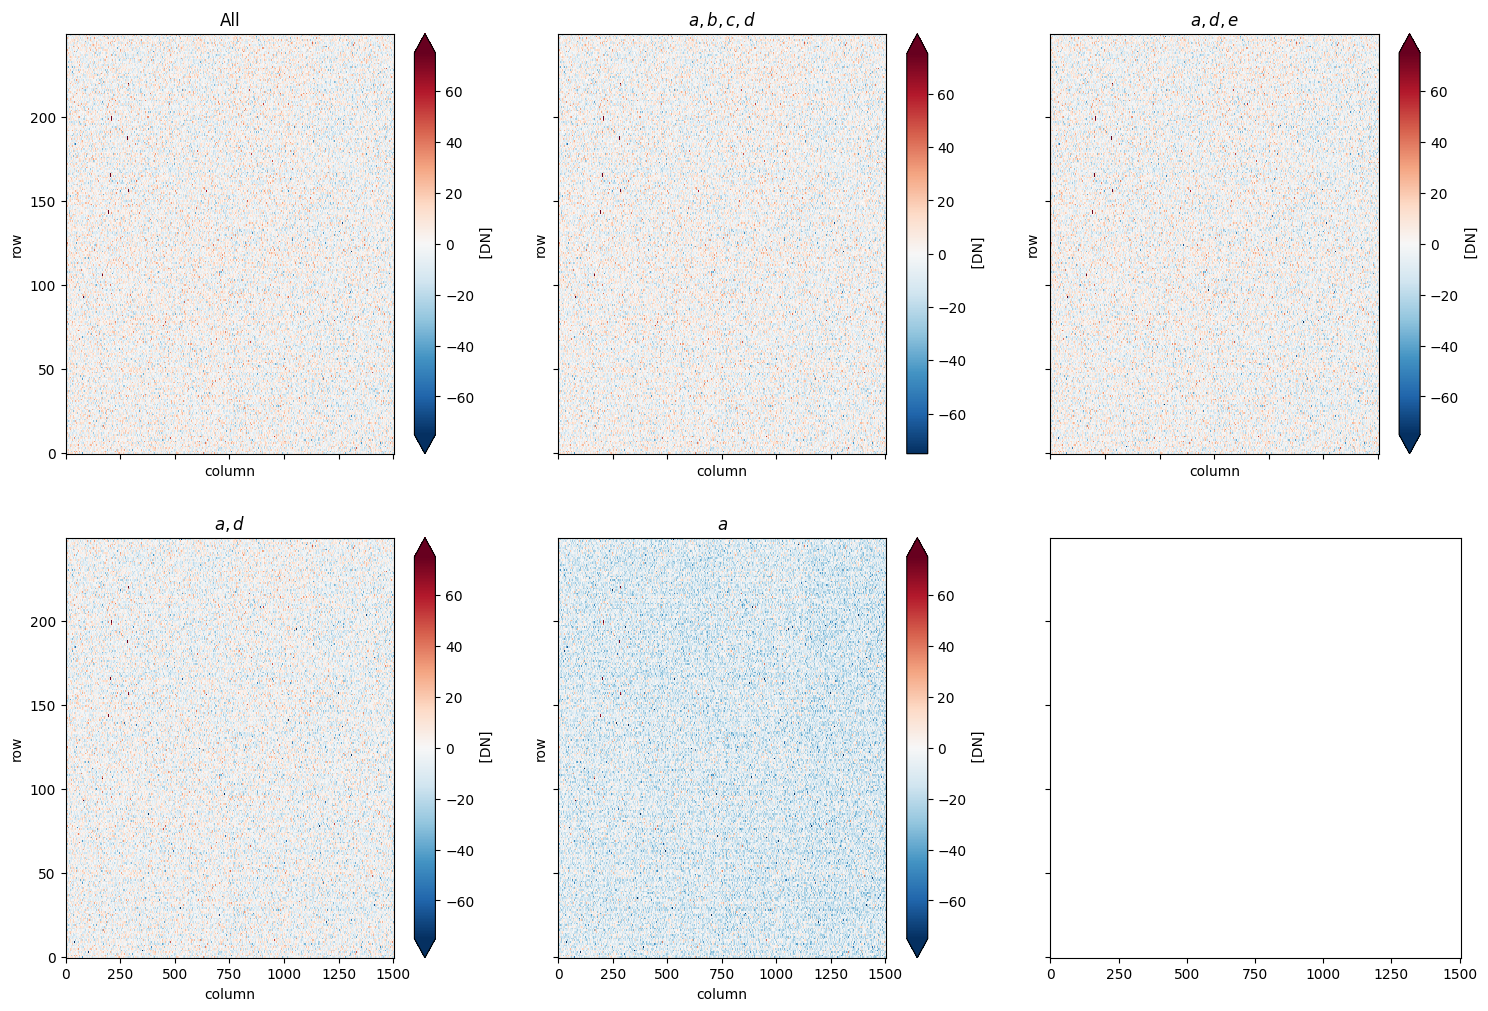

In [20]:
ncol = 3
nrow = 2
fig, axes = plt.subplots(nrow,ncol,figsize=(size*ncol,size*nrow),sharex=True,sharey=True)
norm = ImageNormalize(vmin=-75,vmax=75)
idx_sample = 1000
ped_rem_all[idx_sample,...].plot.imshow(ax=axes[0,0],norm=norm);axes[0,0].set_title('All')
ped_rem_abcd[idx_sample,...].plot.imshow(ax=axes[0,1],norm=norm);axes[0,1].set_title(r'$a,b,c,d$')
ped_rem_ade[idx_sample,...].plot.imshow(ax=axes[0,2],norm=norm);axes[0,2].set_title(r'$a,d,e$')
ped_rem_ad[idx_sample,...].plot.imshow(ax=axes[1,0],norm=norm);axes[1,0].set_title(r'$a,d$')
ped_rem_a[idx_sample,...].plot.imshow(ax=axes[1,1],norm=norm);axes[1,1].set_title(r'$a$')
#axes[0].axes.set_aspect('equal')

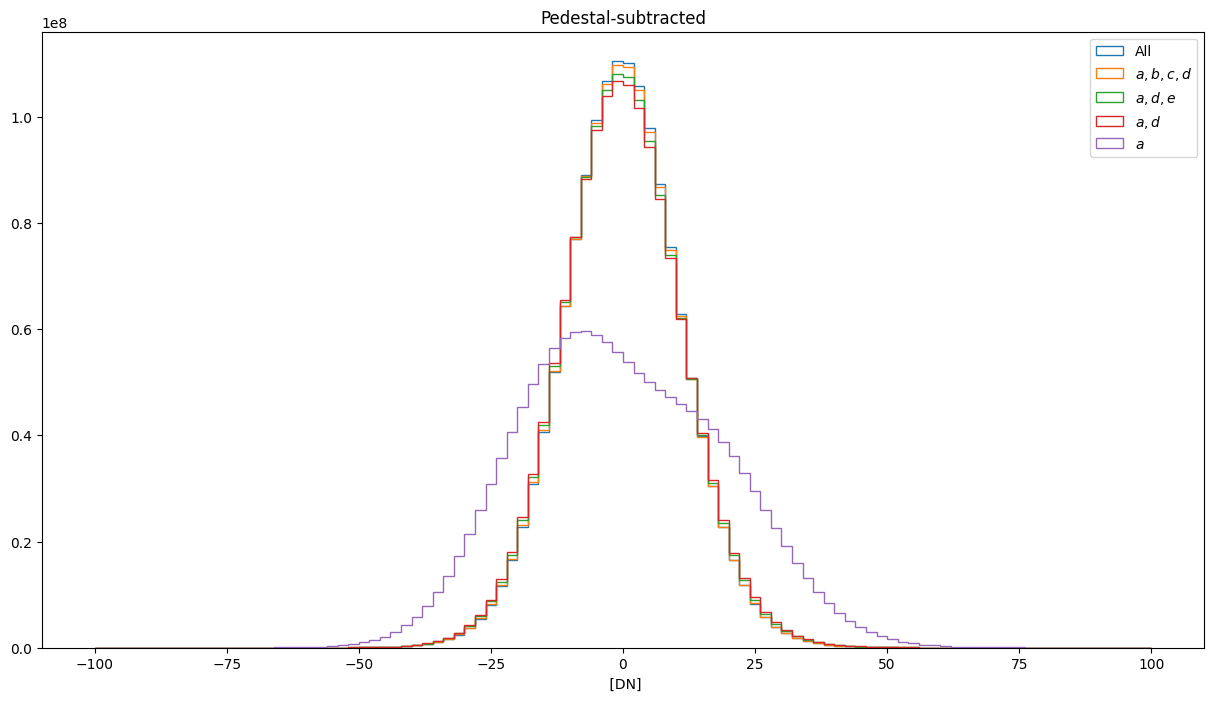

In [16]:
fig = plt.figure(figsize=(15,8))
ax = fig.add_subplot()
_,be,_ = ped_rem_all.plot.hist(ax=ax,bins=100,range=(-100,100),histtype='step',log=False, label='All');
ped_rem_abcd.plot.hist(ax=ax,bins=be,histtype='step',log=False, label=r'$a,b,c,d$')
ped_rem_ade.plot.hist(ax=ax,bins=be,histtype='step',log=False, label=r'$a,d,e$')
ped_rem_ad.plot.hist(ax=ax,bins=be,histtype='step',log=False, label=r'$a,d$')
ped_rem_a.plot.hist(ax=ax,bins=be,histtype='step',log=False, label=r'$a$');
ax.set_title('Pedestal-subtracted')
ax.legend()

## Sandbox